# Fourier Analysis of Molecular Hamiltonian Expectation Values

Using VQE, we want to compute 

\begin{equation}
E(\theta) = \langle \psi(\theta) | H | \psi(\theta) \rangle
\tag{1}
\end{equation}

where $H$ is a molecular hamiltonian. After this, we want to find the optimal angle $\theta^* = \arg\min_\theta E(\theta)$. To gain insight into the structure of $E(\theta)$, we can perform a Fourier analysis. This will allow us to extract the Fourier coefficients and understand how they vary with the H-H distance.


## Molecular Hamiltonians

### $H_2$

The standard VQE Hamiltonian construction for $H_2$ follows the steps:

1. Obtain the eletronic Hamiltonian in termos of fermion operators ($a_p$ and $a_p^{\dagger}$): `build_electronic_hamiltonian()`
2. Map the eletronic Hamiltonian to the qubit one in terms of Pauli strings: `build_qubit_hamiltonian()`

In the final step, we extract the Pauli strings using `pauli_terms_from_qubit_hamiltonian()`.

In [1]:
from src.vqe.hamiltonian import (
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

ferm_op, constant_energy = build_electronic_hamiltonian(
    atom_string="H 0 0 0; H 0 0 0.74",
    basis="sto-3g",
    active_space=(2, 2),
    freeze_core=False,
)

qubit_op = build_qubit_hamiltonian(ferm_op, mapper="jw")
terms = pauli_terms_from_qubit_hamiltonian(qubit_op)

print("constant_energy:", constant_energy)
for pauli, coeff in terms:
    print(coeff, pauli)

constant_energy: 0.7151043390810812
-0.8121706072487132 IIII
0.17141282644776906 IIIZ
-0.2234315369081336 IIZI
0.12062523483390414 IIZZ
0.17141282644776912 IZII
0.16868898170361202 IZIZ
-0.2234315369081336 ZIII
0.16592785033770333 ZIIZ
0.04530261550379917 YYYY
0.04530261550379917 XXYY
0.04530261550379917 YYXX
0.04530261550379917 XXXX
0.16592785033770333 IZZI
0.1744128761226153 ZIZI
0.12062523483390414 ZZII


It is possible to reduce the number of qubits/Pauli terms if we use parity symmetry:

In [5]:
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

atom = "H 0 0 0; H 0 0 0.74"

problem = build_electronic_problem(
    atom_string=atom,
    basis="sto-3g",
    active_space=(2, 2),
    freeze_core=False,
)

ferm_op, const = build_electronic_hamiltonian(
    atom_string=atom,
    basis="sto-3g",
    active_space=(2, 2),
    freeze_core=False,
)

qubit_op_2q = build_qubit_hamiltonian(
    ferm_op,
    mapper="parity",
    z2symmetry_reduction=False,   # mantém em 2 qubits
    problem=problem,
    num_particles=problem.num_particles,
)

print("num_qubits:", qubit_op_2q.num_qubits)
print(pauli_terms_from_qubit_hamiltonian(qubit_op_2q)[:10])

num_qubits: 2
[('II', -1.053421076916521), ('IZ', 0.39484436335590256), ('ZI', -0.3948443633559026), ('ZZ', -0.011246157150820668), ('XX', 0.1812104620151967)]


This result almost matches Kandala et al (2017), up to relative signs: 

``` (ZZ 0.011280 ZI 0.397936 IZ 0.397936  XX 0.180931). ```

We can also use a Z2 symmetry reduction to reduce even further the hamiltonian to 1 qubit. Let us test which Hamiltonian gives the best match to the exact FCI result: 

In [6]:
import numpy as np
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import build_qubit_hamiltonian

# Build three H2 Hamiltonians from the same electronic problem
qubit_ops = {
    "4q_jw": build_qubit_hamiltonian(ferm_op, mapper="jw"),
    "2q_parity": build_qubit_hamiltonian(
        ferm_op,
        mapper="parity",
        z2symmetry_reduction=False,
        problem=problem,
        num_particles=problem.num_particles,
    ),
    "1q_parity_z2": build_qubit_hamiltonian(
        ferm_op,
        mapper="parity",
        z2symmetry_reduction=True,
        problem=problem,
        num_particles=problem.num_particles,
    ),
}

rows = []
for label, qop in qubit_ops.items():
    ansatz = build_ansatz(
        name="real_amplitudes",
        num_qubits=qop.num_qubits,
        reps=2,
    )
    optimizer = get_optimizer("cobyla", max_iter=200)

    vqe_res = run_vqe(
        qubit_op=qop,
        ansatz=ansatz,
        optimizer=optimizer,
        constant_energy=float(const),
        seed=137,
    )

    exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
    exact_total = float(np.real(exact.eigenvalue) + float(const))

    rows.append({
        "hamiltonian": label,
        "num_qubits": qop.num_qubits,
        "vqe_total_energy": float(vqe_res["energy"]),
        "exact_total_energy": exact_total,
        "abs_error": abs(float(vqe_res["energy"]) - exact_total),
        "eval_count": int(vqe_res["eval_count"]),
    })

rows = sorted(rows, key=lambda x: x["num_qubits"], reverse=True)
for row in rows:
    print(row)

{'hamiltonian': '4q_jw', 'num_qubits': 4, 'vqe_total_energy': -1.1167590753609047, 'exact_total_energy': -1.1372838344885006, 'abs_error': 0.020524759127595882, 'eval_count': 200}
{'hamiltonian': '2q_parity', 'num_qubits': 2, 'vqe_total_energy': -1.1372838335556938, 'exact_total_energy': -1.1372838344885001, 'abs_error': 9.328062766655876e-10, 'eval_count': 76}
{'hamiltonian': '1q_parity_z2', 'num_qubits': 1, 'vqe_total_energy': -1.137283834480362, 'exact_total_energy': -1.1372838344885003, 'abs_error': 8.138378859712248e-12, 'eval_count': 36}


### LiH (not working with FCI)

First we obtain the simplest Hamiltonian with an active space (2,2).

In [5]:
import importlib
import numpy as np

if not hasattr(np, "in1d"):
    np.in1d = np.isin

import src.vqe.hamiltonian as hamiltonian_mod
importlib.reload(hamiltonian_mod)

build_electronic_problem = hamiltonian_mod.build_electronic_problem
build_electronic_hamiltonian = hamiltonian_mod.build_electronic_hamiltonian
build_qubit_hamiltonian = hamiltonian_mod.build_qubit_hamiltonian
pauli_terms_from_qubit_hamiltonian = hamiltonian_mod.pauli_terms_from_qubit_hamiltonian

# LiH at a representative bond length (Angstrom)
atom_lih = "Li 0 0 0; H 0 0 1.545"

# Kandala-like approximation for LiH in STO-3G:
# - freeze Li 1s core
# - keep 3 spatial orbitals (=> 6 spin-orbitals)
# - with 2 active electrons => CAS(2,3)
# The explicit active_orbitals selection lets us exclude two orbitals consistently.
active_space_kandala = (2, 3)
active_orbitals_kandala = [0, 1, 2]

ferm_op_lih, constant_energy_lih = build_electronic_hamiltonian(
    atom_string=atom_lih,
    basis="sto-3g",
    active_space=active_space_kandala,
    active_orbitals=active_orbitals_kandala,
    freeze_core=True,
)

problem_ref = build_electronic_problem(
    atom_string=atom_lih,
    basis="sto-3g",
    active_space=active_space_kandala,
    active_orbitals=active_orbitals_kandala,
    freeze_core=True,
)

qubit_op_lih = build_qubit_hamiltonian(
    ferm_op_lih,
    mapper="bk",
    z2symmetry_reduction=True,
    problem=problem_ref,
)
terms_lih = pauli_terms_from_qubit_hamiltonian(qubit_op_lih)

print("atom:", atom_lih)
print("active_space:", active_space_kandala)
print("active_orbitals:", active_orbitals_kandala)
print("constant_energy:", constant_energy_lih)
print("num_qubits:", qubit_op_lih.num_qubits)
print("num_pauli_terms:", len(terms_lih))
for pauli, coeff in terms_lih:
    print(coeff, pauli)

atom: Li 0 0 0; H 0 0 1.545
active_space: (2, 3)
active_orbitals: [0, 1, 2]
constant_energy: -6.792223915021593
num_qubits: 3
num_pauli_terms: 34
-0.3931381946187643 III
-0.10300198309489338 IIZ
0.2757166284318585 ZZZ
-0.4271332638578527 ZZI
0.10300198309489349 ZII
-0.2073911576914914 ZIZ
-0.01360522854452937 YYI
-0.013605224753044659 YYZ
0.01360522854452937 XXI
0.013605224753044659 XXZ
-0.2757166284318586 IZI
0.11261387963466069 IZZ
0.013605228544529373 ZZX
0.013605228544529373 IIX
-0.013605224753044659 IZX
-0.013605224753044659 ZIX
0.0062679403102556975 XXX
-0.0062679403102556975 YYX
-0.005932312376703485 XIX
-0.005932312376703485 XZX
-0.005932312376703485 YZY
-0.005932312376703485 YIY
0.004808814870608493 ZXX
-0.004808814870608493 IXX
0.004808814870608493 IYY
-0.004808814870608493 ZYY
-0.004808814870608493 XIZ
-0.004808814870608493 XZZ
-0.004808814870608493 XII
-0.004808814870608493 XZI
0.01032333803518957 ZXZ
-0.01032333803518957 IXZ
0.01032333803518957 ZXI
-0.01032333803518957 IXI

Distance grid source: fci_aa63164e25.csv
Distance range: (0.8125, 4.875)
Num points selected: 105 out of 105
Selected setup:
{'active_space': (2, 3), 'active_orbitals': [0, 1, 2], 'freeze_core': True, 'mapper': 'bk', 'z2': True, 'use_num_particles': True, 'num_qubits_ref': 3, 'num_terms_ref': 34, 'constant_energy_ref': -6.945037935279816}
Fully loaded from cache (105 rows).


,distance,atom,basis,active_space,active_orbitals,freeze_core,mapper,z2,use_num_particles,num_qubits,...,exact_vs_ref_abs_error,vqe_vs_exact_abs_error,vqe_vs_ref_abs_error,eval_count,ansatz_name,ansatz_reps,optimizer,optimizer_max_iter,seed,status
0,0.812500,Li 0 0 0; H 0 0 0.8125,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,2.664535e-15,1.401077e-08,1.401077e-08,507,real_amplitudes,4,cobyla,600,137,ok
1,0.853535,Li 0 0 0; H 0 0 0.8535353535353536,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,0.000000e+00,9.936685e-09,9.936685e-09,550,real_amplitudes,4,cobyla,600,137,ok
2,0.894571,Li 0 0 0; H 0 0 0.8945707070707071,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,8.881784e-16,1.453641e-07,1.453641e-07,600,real_amplitudes,4,cobyla,600,137,ok
3,0.900000,Li 0 0 0; H 0 0 0.9,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,8.881784e-16,3.319488e-07,3.319488e-07,600,real_amplitudes,4,cobyla,600,137,ok
4,0.935606,Li 0 0 0; H 0 0 0.9356060606060606,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,5.329071e-15,7.284356e-09,7.284362e-09,574,real_amplitudes,4,cobyla,600,137,ok
5,0.976641,Li 0 0 0; H 0 0 0.976641414141414,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,3.552714e-15,5.973633e-09,5.973637e-09,503,real_amplitudes,4,cobyla,600,137,ok
6,1.017677,Li 0 0 0; H 0 0 1.0176767676767675,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,8.881784e-16,7.112507e-09,7.112508e-09,435,real_amplitudes,4,cobyla,600,137,ok
7,1.058712,Li 0 0 0; H 0 0 1.058712121212121,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,3.552714e-15,2.428655e-09,2.428658e-09,440,real_amplitudes,4,cobyla,600,137,ok
8,1.099747,Li 0 0 0; H 0 0 1.0997474747474747,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,1.776357e-15,2.521763e-09,2.521765e-09,415,real_amplitudes,4,cobyla,600,137,ok
9,1.140783,Li 0 0 0; H 0 0 1.1407828282828285,sto-3g,"(2, 3)","[0, 1, 2]",True,bk,True,True,3,...,3.552714e-15,8.214278e-09,8.214275e-09,414,real_amplitudes,4,cobyla,600,137,ok


,points_used,num_qubits_mode,num_terms_mode,min_exact_total_energy,min_vqe_total_energy,min_ref_energy,mean_exact_vs_ref_abs_error,mean_vqe_vs_exact_abs_error,mean_vqe_vs_ref_abs_error,mean_eval_count
0,105,3,34,-7.864431,-7.864431,-7.864431,2.633817e-10,0.000846,0.000846,572.838095


Saved figure: /Users/fabio/workspace/projects/PIBIC-FACEPE-2025-yann/pibic-yann-2025/códigos-yann/vqe-quantum-simulation/data/LiH/sto-3g/figures/lih_curve_mode-cas23_basis-sto-3g_mapper-bk_active-2e3o_activeorb-0-1-2_freeze-true_z2-true_numpart-true_ansatz-real_amplitudes-r4_opt-cobyla-600_seed-137_pts-105.png


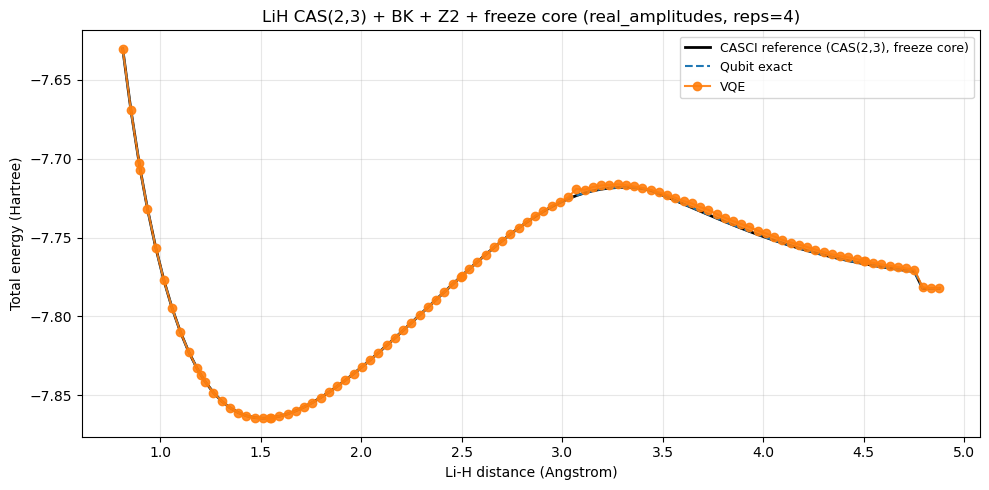

In [7]:
import importlib
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
import src.vqe.hamiltonian as hamiltonian_mod
from src.data.cache import cache_fci

importlib.reload(hamiltonian_mod)
build_electronic_problem = hamiltonian_mod.build_electronic_problem
build_electronic_hamiltonian = hamiltonian_mod.build_electronic_hamiltonian
build_qubit_hamiltonian = hamiltonian_mod.build_qubit_hamiltonian


def _slug(value: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]+", "-", str(value)).strip("-").lower()


def lih_geom(d: float) -> str:
    return f"Li 0 0 0; H 0 0 {float(d)}"


cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "src").exists() else cwd.parent

# Reuse distance grid from latest LiH cache file
fci_dir = project_root / "data" / "LiH" / "sto-3g"
fci_files = sorted(fci_dir.glob("fci_*.csv"), key=lambda p: p.stat().st_mtime)
if not fci_files:
    raise FileNotFoundError(f"No LiH FCI cache files found in {fci_dir}")

distance_source = pd.read_csv(fci_files[-1]).sort_values("distance").reset_index(drop=True)

# Quick control for how many geometry points to evaluate in this run.
# Set to None to use all points from the source FCI grid.
max_points = None

all_distances = distance_source["distance"].values
if (max_points is None) or (int(max_points) >= len(all_distances)):
    distances_eval = all_distances
else:
    idx = np.linspace(0, len(all_distances) - 1, int(max_points), dtype=int)
    distances_eval = all_distances[idx]

# Optional figure export for reports.
save_figure = True
figure_dir = project_root / "data" / "LiH" / "sto-3g" / "figures"

print("Distance grid source:", fci_files[-1].name)
print("Distance range:", (float(distances_eval.min()), float(distances_eval.max())))
print("Num points selected:", len(distances_eval), "out of", len(all_distances))

# Kandala-like target setup
basis = "sto-3g"
active_space = (2, 3)  # (num_electrons, num_orbitals)
active_orbitals = active_orbitals_kandala if "active_orbitals_kandala" in globals() else [0, 1, 2]
freeze_core = True
mapper = "bk"
z2 = True
use_num_particles = True

ansatz_name = "real_amplitudes"
ansatz_reps = 4
optimizer_name = "cobyla"
optimizer_max_iter = 600
seed = 137

# FCI/CASCI reference from cache using the same active-space size
fci_ref = cache_fci(
    molecule="LiH",
    geometry_fn=lih_geom,
    distances=distances_eval,
    basis=basis,
    active_space=active_space,
    homo_lumo_window=2,
    freeze_core=1 if freeze_core else 0,
    data_dir=project_root / "data",
    overwrite=False,
    verbose=False,
)

fci_ref_df = pd.DataFrame({
    "distance": distances_eval,
    "energy": fci_ref,
}).dropna().sort_values("distance").reset_index(drop=True)

if fci_ref_df.empty:
    raise RuntimeError("CASCI/FCI reference is empty for this setup.")

# Probe representative geometry to report qubit and term counts
d_ref = float(distances_eval[len(distances_eval) // 2])
atom_ref = lih_geom(d_ref)

problem_ref = build_electronic_problem(
    atom_string=atom_ref,
    basis=basis,
    active_space=active_space,
    active_orbitals=active_orbitals,
    freeze_core=freeze_core,
)
ferm_ref, const_ref = build_electronic_hamiltonian(
    atom_string=atom_ref,
    basis=basis,
    active_space=active_space,
    active_orbitals=active_orbitals,
    freeze_core=freeze_core,
)
qop_ref = build_qubit_hamiltonian(
    ferm_ref,
    mapper=mapper,
    z2symmetry_reduction=z2,
    problem=problem_ref,
    num_particles=problem_ref.num_particles if use_num_particles else None,
).simplify(atol=0.0)

print("Selected setup:")
print({
    "active_space": active_space,
    "active_orbitals": active_orbitals,
    "freeze_core": freeze_core,
    "mapper": mapper,
    "z2": z2,
    "use_num_particles": use_num_particles,
    "num_qubits_ref": int(qop_ref.num_qubits),
    "num_terms_ref": int(len(qop_ref.paulis)),
    "constant_energy_ref": float(const_ref),
})

# Persistent cache for this exact config
cache_dir = project_root / "data" / "LiH" / "sto-3g" / "vqe_cache"
cache_dir.mkdir(parents=True, exist_ok=True)

cfg_tag = "_".join(
    [
        "mode-cas23",
        f"basis-{_slug(basis)}",
        f"mapper-{_slug(mapper)}",
        f"active-{active_space[0]}e{active_space[1]}o",
        f"activeorb-{_slug('-'.join(str(i) for i in active_orbitals))}",
        f"freeze-{_slug(freeze_core)}",
        f"z2-{_slug(z2)}",
        f"numpart-{_slug(use_num_particles)}",
        f"ansatz-{_slug(ansatz_name)}-r{ansatz_reps}",
        f"opt-{_slug(optimizer_name)}-{optimizer_max_iter}",
        f"seed-{seed}",
    ]
)

cache_csv = cache_dir / f"lih_vqe_{cfg_tag}.csv"
cache_json = cache_dir / f"lih_vqe_{cfg_tag}.json"

if cache_csv.exists():
    cache_df = pd.read_csv(cache_csv)
else:
    cache_df = pd.DataFrame()

cached_keys = set()
if not cache_df.empty and "distance" in cache_df.columns:
    cached_keys = {f"{float(d):.8f}" for d in cache_df["distance"].tolist()}

pending_distances = [d for d in fci_ref_df["distance"].values if f"{float(d):.8f}" not in cached_keys]

if pending_distances:
    print(f"Computing {len(pending_distances)} missing points...")
else:
    print(f"Fully loaded from cache ({len(cache_df)} rows).")

new_rows = []
for d in pending_distances:
    d = float(d)
    atom = lih_geom(d)
    ref_energy = float(fci_ref_df.loc[np.isclose(fci_ref_df["distance"].values, d), "energy"].iloc[0])

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )
    ferm_op, const = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )

    qop = build_qubit_hamiltonian(
        ferm_op,
        mapper=mapper,
        z2symmetry_reduction=z2,
        problem=problem,
        num_particles=problem.num_particles if use_num_particles else None,
    ).simplify(atol=0.0)

    exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
    exact_total = float(np.real(exact.eigenvalue) + float(const))

    ansatz = build_ansatz(name=ansatz_name, num_qubits=qop.num_qubits, reps=ansatz_reps)
    optimizer = get_optimizer(optimizer_name, max_iter=optimizer_max_iter)
    vqe_res = run_vqe(
        qubit_op=qop,
        ansatz=ansatz,
        optimizer=optimizer,
        constant_energy=float(const),
        seed=seed,
    )

    new_rows.append(
        {
            "distance": d,
            "atom": atom,
            "basis": basis,
            "active_space": str(active_space),
            "active_orbitals": str(active_orbitals),
            "freeze_core": bool(freeze_core),
            "mapper": mapper,
            "z2": bool(z2),
            "use_num_particles": bool(use_num_particles),
            "num_qubits": int(qop.num_qubits),
            "num_terms": int(len(qop.paulis)),
            "constant_energy": float(const),
            "ref_energy": ref_energy,
            "exact_total_energy": exact_total,
            "vqe_total_energy": float(vqe_res["energy"]),
            "exact_vs_ref_abs_error": abs(exact_total - ref_energy),
            "vqe_vs_exact_abs_error": abs(float(vqe_res["energy"]) - exact_total),
            "vqe_vs_ref_abs_error": abs(float(vqe_res["energy"]) - ref_energy),
            "eval_count": int(vqe_res["eval_count"]),
            "ansatz_name": ansatz_name,
            "ansatz_reps": ansatz_reps,
            "optimizer": optimizer_name,
            "optimizer_max_iter": optimizer_max_iter,
            "seed": seed,
            "status": "ok",
        }
    )

if new_rows:
    new_df = pd.DataFrame(new_rows)
    cache_df = pd.concat([cache_df, new_df], ignore_index=True)

if not cache_df.empty:
    cache_df = cache_df.drop_duplicates(subset=["distance"], keep="last")
    cache_df = cache_df.sort_values(["distance"]).reset_index(drop=True)
    cache_df.to_csv(cache_csv, index=False)

    cache_meta = {
        "cache_csv": str(cache_csv),
        "reference": "cache_fci(active_space=(2,3), freeze_core=1)",
        "settings": {
            "basis": basis,
            "active_space": active_space,
            "active_orbitals": active_orbitals,
            "freeze_core": freeze_core,
            "mapper": mapper,
            "z2symmetry_reduction": z2,
            "use_num_particles": use_num_particles,
            "ansatz_name": ansatz_name,
            "ansatz_reps": ansatz_reps,
            "optimizer": optimizer_name,
            "optimizer_max_iter": optimizer_max_iter,
            "seed": seed,
        },
        "rows_total": int(len(cache_df)),
    }
    cache_json.write_text(json.dumps(cache_meta, indent=2), encoding="utf-8")

result_df = cache_df.copy()
result_df = result_df[result_df["status"] == "ok"].copy()
result_df = result_df[result_df["distance"].isin(distances_eval)].copy()
if result_df.empty:
    raise RuntimeError("No points were produced for CAS(2,3)+BK+Z2+freeze_core.")

display(result_df.head(12))

summary_df = pd.DataFrame(
    [
        {
            "points_used": int(len(result_df)),
            "num_qubits_mode": int(result_df["num_qubits"].mode().iloc[0]),
            "num_terms_mode": int(result_df["num_terms"].mode().iloc[0]),
            "min_exact_total_energy": float(result_df["exact_total_energy"].min()),
            "min_vqe_total_energy": float(result_df["vqe_total_energy"].min()),
            "min_ref_energy": float(result_df["ref_energy"].min()),
            "mean_exact_vs_ref_abs_error": float(result_df["exact_vs_ref_abs_error"].mean()),
            "mean_vqe_vs_exact_abs_error": float(result_df["vqe_vs_exact_abs_error"].mean()),
            "mean_vqe_vs_ref_abs_error": float(result_df["vqe_vs_ref_abs_error"].mean()),
            "mean_eval_count": float(result_df["eval_count"].mean()),
        }
    ]
)
display(summary_df)

plt.figure(figsize=(10, 5))
plt.plot(
    result_df["distance"],
    result_df["ref_energy"],
    color="black",
    linewidth=2,
    label="CASCI reference (CAS(2,3), freeze core)",
)
plt.plot(
    result_df["distance"],
    result_df["exact_total_energy"],
    linestyle="--",
    label="Qubit exact",
)
plt.plot(
    result_df["distance"],
    result_df["vqe_total_energy"],
    marker="o",
    alpha=0.9,
    label="VQE",
)

plt.xlabel("Li-H distance (Angstrom)")
plt.ylabel("Total energy (Hartree)")
plt.title(f"LiH CAS(2,3) + BK + Z2 + freeze core ({ansatz_name}, reps={ansatz_reps})")
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()

if save_figure:
    figure_dir.mkdir(parents=True, exist_ok=True)
    figure_name = f"lih_curve_{cfg_tag}_pts-{len(result_df)}.png"
    figure_path = figure_dir / figure_name
    plt.savefig(figure_path, dpi=220, bbox_inches="tight")
    print("Saved figure:", figure_path)
plt.show()

#### Attempts to reproduce Kandala et al (2017) results for LiH

##### LiH: Effect of Active Space on Number of Pauli Terms

To compare with literature values (e.g., Kandala et al. 2017), we sweep different active-space choices and count:
- number of qubits,
- number of Pauli terms in the JW Hamiltonian.

This helps explain why a compact active space can produce far fewer terms.

In [ ]:
import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

atom_lih = "Li 0 0 0; H 0 0 1.60"
basis = "sto-3g"

# (num_active_electrons, num_active_spatial_orbitals)
active_space_grid = [
    (2, 2),
    (2, 3),
    (2, 4),
    (4, 4),
]

rows_lhs = []
for freeze_core in [False, True]:
    for active_space in active_space_grid:
        try:
            ferm_op_tmp, const_tmp = build_electronic_hamiltonian(
                atom_string=atom_lih,
                basis=basis,
                active_space=active_space,
                freeze_core=freeze_core,
            )
            qop_tmp = build_qubit_hamiltonian(ferm_op_tmp, mapper="jw")
            terms_tmp = pauli_terms_from_qubit_hamiltonian(qop_tmp, tolerance=0.0)

            rows_lhs.append(
                {
                    "active_space": str(active_space),
                    "freeze_core": freeze_core,
                    "num_qubits": int(qop_tmp.num_qubits),
                    "num_pauli_terms": int(len(terms_tmp)),
                    "constant_energy": float(const_tmp),
                    "status": "ok",
                }
            )
        except Exception as exc:
            rows_lhs.append(
                {
                    "active_space": str(active_space),
                    "freeze_core": freeze_core,
                    "num_qubits": None,
                    "num_pauli_terms": None,
                    "constant_energy": None,
                    "status": f"error: {exc}",
                }
            )

lih_term_scan_df = pd.DataFrame(rows_lhs)
display(lih_term_scan_df)

ok_df = lih_term_scan_df[lih_term_scan_df["status"] == "ok"].copy()
if not ok_df.empty:
    print("\nConfigurations sorted by number of Pauli terms:")
    display(ok_df.sort_values("num_pauli_terms", ascending=False))

,active_space,freeze_core,num_qubits,num_pauli_terms,constant_energy,status
0,"(2, 2)",False,4.0,27.0,0.992207,ok
1,"(2, 3)",False,6.0,62.0,0.992207,ok
2,"(2, 4)",False,8.0,105.0,0.992207,ok
3,"(4, 4)",False,8.0,193.0,0.992207,ok
4,"(2, 2)",True,4.0,27.0,0.992207,ok
5,"(2, 3)",True,6.0,62.0,0.992207,ok
6,"(2, 4)",True,8.0,105.0,0.992207,ok
7,"(4, 4)",True,NaN,NaN,NaN,error: 'More electrons requested than available.'



Configurations sorted by number of Pauli terms:


,active_space,freeze_core,num_qubits,num_pauli_terms,constant_energy,status
3,"(4, 4)",False,8.0,193.0,0.992207,ok
2,"(2, 4)",False,8.0,105.0,0.992207,ok
6,"(2, 4)",True,8.0,105.0,0.992207,ok
1,"(2, 3)",False,6.0,62.0,0.992207,ok
5,"(2, 3)",True,6.0,62.0,0.992207,ok
0,"(2, 2)",False,4.0,27.0,0.992207,ok
4,"(2, 2)",True,4.0,27.0,0.992207,ok


##### LiH with Parity Mapping (target: 4 qubits, ~99 terms)

This experiment reproduces the LiH setup with parity mapping and reports the number of terms under different settings (with and without Z2 tapering, and optional coefficient thresholds).

In [ ]:
import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

atom_lih = "Li 0 0 0; H 0 0 1.60"
basis = "sto-3g"
active_space = (2, 4)

problem_lih = build_electronic_problem(
    atom_string=atom_lih,
    basis=basis,
    active_space=active_space,
    freeze_core=False,
)

ferm_op_lih, const_lih = build_electronic_hamiltonian(
    atom_string=atom_lih,
    basis=basis,
    active_space=active_space,
    freeze_core=False,
)

# Parity mapping can be inspected both with and without tapering.
parity_ops = {
    "parity_8q_no_taper": build_qubit_hamiltonian(
        ferm_op_lih,
        mapper="parity",
        z2symmetry_reduction=False,
        problem=problem_lih,
        num_particles=problem_lih.num_particles,
    ),
    "parity_4q_z2_taper": build_qubit_hamiltonian(
        ferm_op_lih,
        mapper="parity",
        z2symmetry_reduction=True,
        problem=problem_lih,
        num_particles=problem_lih.num_particles,
    ),
}

tolerances = [0.0, 1e-10, 1e-8, 1e-6, 1e-4]
rows_parity = []

for label, qop in parity_ops.items():
    for tol in tolerances:
        n_terms = len(pauli_terms_from_qubit_hamiltonian(qop, tolerance=tol))
        rows_parity.append(
            {
                "config": label,
                "tolerance": tol,
                "num_qubits": int(qop.num_qubits),
                "num_pauli_terms": int(n_terms),
                "abs_diff_to_99": abs(int(n_terms) - 99),
            }
        )

parity_lh_df = pd.DataFrame(rows_parity).sort_values(
    ["abs_diff_to_99", "config", "tolerance"], ascending=[True, True, True]
)

display(parity_lh_df)

best_row = parity_lh_df.iloc[0]
print(
    f"Best match to 99 terms -> config={best_row['config']}, "
    f"tol={best_row['tolerance']}, qubits={int(best_row['num_qubits'])}, "
    f"terms={int(best_row['num_pauli_terms'])}"
)

,config,tolerance,num_qubits,num_pauli_terms,abs_diff_to_99
0,parity_8q_no_taper,0.000000e+00,6,95,4
1,parity_8q_no_taper,1.000000e-10,6,95,4
2,parity_8q_no_taper,1.000000e-08,6,95,4
3,parity_8q_no_taper,1.000000e-06,6,95,4
4,parity_8q_no_taper,1.000000e-04,6,95,4
5,parity_4q_z2_taper,0.000000e+00,4,62,37
6,parity_4q_z2_taper,1.000000e-10,4,62,37
7,parity_4q_z2_taper,1.000000e-08,4,62,37
8,parity_4q_z2_taper,1.000000e-06,4,62,37
9,parity_4q_z2_taper,1.000000e-04,4,62,37


Best match to 99 terms -> config=parity_8q_no_taper, tol=0.0, qubits=6, terms=95


In [ ]:
import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

atom_lih = "Li 0 0 0; H 0 0 1.60"
basis = "sto-3g"

grid = []
for freeze_core in [False, True]:
    for active_space in [(2, 2), (2, 3), (2, 4), (2, 5), (4, 4), (4, 5)]:
        try:
            problem = build_electronic_problem(
                atom_string=atom_lih,
                basis=basis,
                active_space=active_space,
                freeze_core=freeze_core,
            )
            ferm_op, _ = build_electronic_hamiltonian(
                atom_string=atom_lih,
                basis=basis,
                active_space=active_space,
                freeze_core=freeze_core,
            )

            for z2 in [False, True]:
                for use_num_particles in [False, True]:
                    try:
                        qop = build_qubit_hamiltonian(
                            ferm_op,
                            mapper="parity",
                            z2symmetry_reduction=z2,
                            problem=problem,
                            num_particles=problem.num_particles if use_num_particles else None,
                        )
                        n_terms = len(pauli_terms_from_qubit_hamiltonian(qop, tolerance=0.0))
                        grid.append(
                            {
                                "freeze_core": freeze_core,
                                "active_space": str(active_space),
                                "z2": z2,
                                "use_num_particles": use_num_particles,
                                "num_qubits": int(qop.num_qubits),
                                "num_terms": int(n_terms),
                                "score_to_target": abs(int(qop.num_qubits) - 4) + abs(int(n_terms) - 99),
                            }
                        )
                    except Exception as exc:
                        grid.append(
                            {
                                "freeze_core": freeze_core,
                                "active_space": str(active_space),
                                "z2": z2,
                                "use_num_particles": use_num_particles,
                                "num_qubits": None,
                                "num_terms": None,
                                "score_to_target": None,
                                "error": str(exc),
                            }
                        )
        except Exception as exc:
            grid.append(
                {
                    "freeze_core": freeze_core,
                    "active_space": str(active_space),
                    "z2": None,
                    "use_num_particles": None,
                    "num_qubits": None,
                    "num_terms": None,
                    "score_to_target": None,
                    "error": str(exc),
                }
            )

scan_df = pd.DataFrame(grid)
valid_df = scan_df.dropna(subset=["num_qubits", "num_terms", "score_to_target"]).copy()
valid_df = valid_df.sort_values(["score_to_target", "num_qubits", "num_terms"]).reset_index(drop=True)

display(valid_df.head(20))

exact_4q_99 = valid_df[(valid_df["num_qubits"] == 4) & (valid_df["num_terms"] == 99)]
if not exact_4q_99.empty:
    print("Found exact 4-qubit / 99-term configuration:")
    display(exact_4q_99)
else:
    print("No exact 4-qubit / 99-term configuration found in this grid.")
    print("Closest row:")
    display(valid_df.head(1))

,freeze_core,active_space,z2,use_num_particles,num_qubits,num_terms,score_to_target,error
0,False,"(2, 4)",False,True,6.0,95.0,6.0,NaN
1,True,"(2, 4)",False,True,6.0,95.0,6.0,NaN
2,False,"(2, 4)",False,False,8.0,105.0,10.0,NaN
3,True,"(2, 4)",False,False,8.0,105.0,10.0,NaN
4,False,"(2, 4)",True,False,4.0,62.0,37.0,NaN
5,False,"(2, 4)",True,True,4.0,62.0,37.0,NaN
6,True,"(2, 4)",True,False,4.0,62.0,37.0,NaN
7,True,"(2, 4)",True,True,4.0,62.0,37.0,NaN
8,False,"(2, 3)",False,False,6.0,62.0,39.0,NaN
9,True,"(2, 3)",False,False,6.0,62.0,39.0,NaN


No exact 4-qubit / 99-term configuration found in this grid.
Closest row:


,freeze_core,active_space,z2,use_num_particles,num_qubits,num_terms,score_to_target,error
0,False,"(2, 4)",False,True,6.0,95.0,6.0,NaN


##### LiH (Kandala 2017): extração da Hamiltoniana de referência (99 termos)

Nesta seção, extraímos automaticamente do fonte do artigo (arXiv:1704.05018) a tabela suplementar de LiH (4 qubits, 99 termos) para usar como **alvo de comparação** com a Hamiltoniana gerada pelo pipeline atual.

In [ ]:
from ast import literal_eval
from pathlib import Path
import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)

# Choose the 4-qubit parity configuration with the largest number of terms
if "valid_df" not in globals():
    raise RuntimeError("Run the parity scan cell first (the one that creates valid_df).")

cand_4q = valid_df[valid_df["num_qubits"] == 4].sort_values("num_terms", ascending=False)
if cand_4q.empty:
    raise RuntimeError("No 4-qubit configuration found in valid_df.")

best_4q = cand_4q.iloc[0]
active_space_4q = literal_eval(best_4q["active_space"])
freeze_core_4q = bool(best_4q["freeze_core"])
z2_4q = bool(best_4q["z2"])
use_num_particles_4q = bool(best_4q["use_num_particles"])

atom_lih = "Li 0 0 0; H 0 0 1.60"
basis = "sto-3g"

problem_4q = build_electronic_problem(
    atom_string=atom_lih,
    basis=basis,
    active_space=active_space_4q,
    freeze_core=freeze_core_4q,
)

ferm_op_4q, const_4q = build_electronic_hamiltonian(
    atom_string=atom_lih,
    basis=basis,
    active_space=active_space_4q,
    freeze_core=freeze_core_4q,
)

qop_4q = build_qubit_hamiltonian(
    ferm_op_4q,
    mapper="parity",
    z2symmetry_reduction=z2_4q,
    problem=problem_4q,
    num_particles=problem_4q.num_particles if use_num_particles_4q else None,
).simplify(atol=0.0)

labels_4q = qop_4q.paulis.to_labels()
coeffs_4q = qop_4q.coeffs

lih4q_terms_df = pd.DataFrame(
    {
        "pauli": labels_4q,
        "coef_real": [float(c.real) for c in coeffs_4q],
        "coef_imag": [float(c.imag) for c in coeffs_4q],
        "abs_coef": [float(abs(c)) for c in coeffs_4q],
    }
).sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("Chosen 4-qubit config (max terms):")
print("active_space:", active_space_4q)
print("freeze_core:", freeze_core_4q)
print("z2symmetry_reduction:", z2_4q)
print("use_num_particles:", use_num_particles_4q)
print("num_qubits:", qop_4q.num_qubits)
print("num_terms:", len(lih4q_terms_df))
print("constant_energy:", float(const_4q))
display(lih4q_terms_df)

output_dir = Path.cwd() / "data" / "LiH" / "sto-3g"
output_dir.mkdir(parents=True, exist_ok=True)
output_csv_4q = output_dir / "lih_parity_4q_max_terms_coefficients.csv"
lih4q_terms_df.to_csv(output_csv_4q, index=False)
print("Saved coefficients to:", output_csv_4q)

Chosen 4-qubit config (max terms):
active_space: (2, 4)
freeze_core: False
z2symmetry_reduction: True
use_num_particles: False
num_qubits: 4
num_terms: 62
constant_energy: 0.992207270475


,pauli,coef_real,coef_imag,abs_coef
0,ZIII,-0.594080,0.0,0.594080
1,ZZII,-0.594080,0.0,0.594080
2,IZIZ,0.276393,0.0,0.276393
3,IZZI,-0.276393,0.0,0.276393
4,IIII,0.212242,0.0,0.212242
...,...,...,...,...
57,ZZXI,0.003871,0.0,0.003871
58,ZIIZ,-0.001446,0.0,0.001446
59,ZIZI,0.001446,0.0,0.001446
60,ZZIZ,-0.001446,0.0,0.001446


Saved coefficients to: /Users/fabio/workspace/projects/PIBIC-FACEPE-2025-yann/pibic-yann-2025/códigos-yann/vqe-quantum-simulation/notebooks/data/LiH/sto-3g/lih_parity_4q_max_terms_coefficients.csv


The coefficients and Pauli terms are printed, and the results are saved to a CSV file for further analysis. We see that with 4 qubits and Z2 tapering there are 62 terms. The numerical coefficientes do not match Kandala et al. (2017). 

In [ ]:
import ast
import re
import tarfile
import tempfile
from pathlib import Path
from urllib.request import urlretrieve

import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)


def _normalize_active_space(value):
    if isinstance(value, str):
        try:
            value = ast.literal_eval(value)
        except Exception:
            return (2, 2)
    if isinstance(value, (list, tuple)) and len(value) >= 2:
        return (int(value[0]), int(value[1]))
    return (2, 2)


# 1) Resolve raiz do projeto.
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

# 2) Baixa e lê o .tex do arXiv sem deixar cache grande no repositório.
with tempfile.TemporaryDirectory() as tmpdir:
    tmpdir_path = Path(tmpdir)
    archive_path = tmpdir_path / "arxiv_1704_05018.tar.gz"
    urlretrieve("https://arxiv.org/e-print/1704.05018", archive_path)

    with tarfile.open(archive_path, "r:gz") as tar:
        tex_member = next((m for m in tar.getmembers() if m.name.endswith("HardwareEffEigensolver.tex")), None)
        if tex_member is None:
            raise RuntimeError("Arquivo HardwareEffEigensolver.tex nao encontrado no fonte do arXiv.")
        tar.extract(tex_member, tmpdir)

    tex_candidates = list(tmpdir_path.rglob("HardwareEffEigensolver.tex"))
    if not tex_candidates:
        raise RuntimeError("Nao foi possivel localizar o .tex extraido do arXiv.")
    tex = tex_candidates[0].read_text(encoding="utf-8", errors="ignore")

# 3) Extrai bloco LiH da tabela suplementar.
start = tex.find("{\\large LiH at bond distance}")
end = tex.find("{\\large BeH$_2$ at bond distance}")
if start == -1 or end == -1:
    raise RuntimeError("Nao foi possivel localizar o bloco LiH/BeH2 na tabela do artigo.")

lih_block = tex[start:end]
matches = re.findall(r"\n([IXYZ]{4})\\\\\s*\n([+-]?\d+\.\d+)\\\\", lih_block)

kandala_lih_df = (
    pd.DataFrame(matches, columns=["pauli", "coef_paper"])
    .assign(coef_paper=lambda d: d["coef_paper"].astype(float))
    .drop_duplicates(subset=["pauli"], keep="first")
    .sort_values("pauli")
    .reset_index(drop=True)
)

print("Termos extraidos da tabela do paper (LiH):", len(kandala_lih_df))

# 4) Salva CSV de referencia do paper.
out_dir = project_root / "notebooks" / "data" / "LiH" / "sto-3g"
out_dir.mkdir(parents=True, exist_ok=True)
paper_csv = out_dir / "lih_kandala_2017_tableS_99_terms.csv"
kandala_lih_df.to_csv(paper_csv, index=False)
print("CSV de referencia salvo em:", paper_csv)

# 5) Compara com a melhor configuracao 4q local encontrada (ou fallback).
atom_lih = "Li 0 0 0; H 0 0 1.5949"

if "best_4q" in globals() and getattr(best_4q, "shape", (0,))[0] != 0:
    cfg_active = _normalize_active_space(best_4q.get("active_space", (2, 2)))
    cfg_freeze = bool(best_4q.get("freeze_core", True))
    cfg_z2 = bool(best_4q.get("z2", best_4q.get("z2_reduction", False)))
    cfg_use_np = bool(best_4q.get("use_num_particles", False))
else:
    cfg_active = (2, 2)
    cfg_freeze = True
    cfg_z2 = True
    cfg_use_np = False

problem_ref = build_electronic_problem(
    atom_string=atom_lih,
    basis="sto-3g",
    active_space=cfg_active,
    freeze_core=cfg_freeze,
)
ferm_ref = problem_ref.hamiltonian.second_q_op()
qop_ref = build_qubit_hamiltonian(
    ferm_ref,
    mapper="parity",
    z2symmetry_reduction=cfg_z2,
    problem=problem_ref,
    num_particles=problem_ref.num_particles if cfg_use_np else None,
)

local_terms = pauli_terms_from_qubit_hamiltonian(qop_ref, tolerance=1e-12)
local_df = pd.DataFrame(local_terms, columns=["pauli", "coef_local"]).sort_values("pauli")

cmp_df = kandala_lih_df.merge(local_df, on="pauli", how="outer").fillna(0.0)
cmp_df["abs_diff"] = (cmp_df["coef_paper"] - cmp_df["coef_local"]).abs()
cmp_df = cmp_df.sort_values("abs_diff", ascending=False).reset_index(drop=True)

print("\nConfiguracao local comparada:")
print(
    {
        "active_space": cfg_active,
        "freeze_core": cfg_freeze,
        "z2": cfg_z2,
        "use_num_particles": cfg_use_np,
        "num_qubits": qop_ref.num_qubits,
    }
)
print("\nResumo da comparacao")
print("- termos paper:", len(kandala_lih_df))
print("- termos locais:", len(local_df))
print("- intersecao de strings:", int((cmp_df["coef_paper"].ne(0) & cmp_df["coef_local"].ne(0)).sum()))

display(cmp_df.head(20))

Termos extraidos da tabela do paper (LiH): 99
CSV de referencia salvo em: /Users/fabio/workspace/projects/PIBIC-FACEPE-2025-yann/pibic-yann-2025/códigos-yann/vqe-quantum-simulation/notebooks/data/LiH/sto-3g/lih_kandala_2017_tableS_99_terms.csv

Configuracao local comparada:
{'active_space': (2, 4), 'freeze_core': False, 'z2': True, 'use_num_particles': False, 'num_qubits': 4}

Resumo da comparacao
- termos paper: 99
- termos locais: 62
- intersecao de strings: 49


,pauli,coef_paper,coef_local,abs_diff
0,ZIII,-0.096022,-0.593851,0.497829
1,ZZII,-0.206128,-0.593851,0.387723
2,IZZI,0.110811,-0.276355,0.387166
3,IZIZ,-0.095216,0.276355,0.371571
4,IIIZ,-0.364746,-0.102554,0.262192
5,IIII,0.000000,0.210973,0.210973
6,IZII,0.364746,0.165401,0.199345
7,IZZZ,-0.063673,0.111878,0.175551
8,ZIZI,-0.145438,0.001334,0.146772
9,ZIIZ,0.110811,-0.001334,0.112145


## Ground-State Energy Curve vs Interatomic Distance

This section sweeps the H-H bond distance and computes the ground-state energy with VQE for each Hamiltonian encoding:
- `4q_jw`
- `2q_parity`
- `1q_parity_z2`

For each case, we also compute the exact minimum eigenvalue of the same qubit Hamiltonian for reference.

,distance,hamiltonian,num_qubits,num_terms,vqe_total_energy,exact_total_energy,abs_error,eval_count
0,0.500000,4q_jw,4,15,-1.041780,-1.055160,1.337930e-02,120
1,0.500000,2q_parity,2,5,-1.055160,-1.055160,1.138640e-09,70
2,0.500000,1q_parity_z2,1,3,-1.055160,-1.055160,9.767960e-10,35
3,0.605263,4q_jw,4,15,-1.102772,-1.118138,1.536626e-02,120
4,0.605263,2q_parity,2,5,-1.118138,-1.118138,2.186849e-09,64
5,0.605263,1q_parity_z2,1,3,-1.118138,-1.118138,7.967849e-12,33
6,0.710526,4q_jw,4,15,-1.117483,-1.136774,1.929162e-02,120
7,0.710526,2q_parity,2,5,-1.136774,-1.136774,1.749779e-09,75
8,0.710526,1q_parity_z2,1,3,-1.136774,-1.136774,1.093393e-09,36


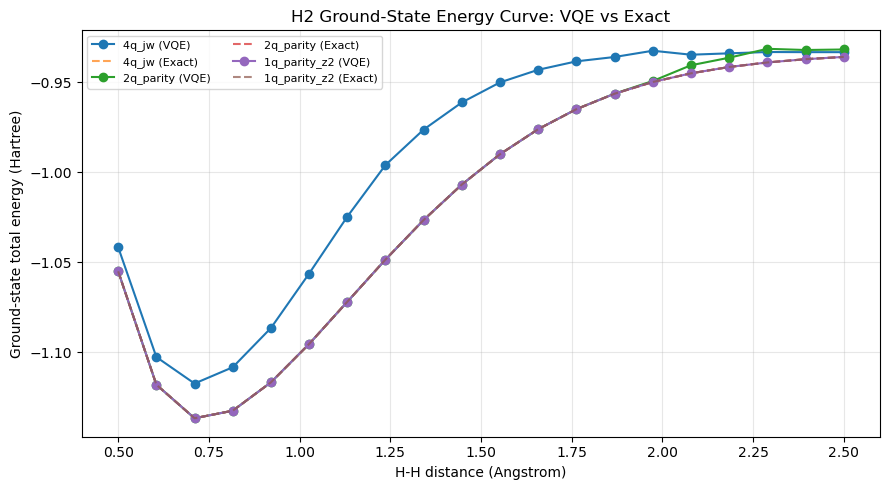

,hamiltonian,num_qubits,mean_abs_error,max_abs_error,mean_eval_count
2,4q_jw,4,2.522873e-02,5.254063e-02,120.00
1,2q_parity,2,1.353212e-03,7.575913e-03,102.55
0,1q_parity_z2,1,3.895955e-10,1.432185e-09,35.95


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
 )

distances = np.linspace(0.5, 2.5, 20)
basis = "sto-3g"
active_space = (2, 2)

rows = []
for d in distances:
    atom = f"H 0 0 0; H 0 0 {d}"

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )
    ferm_op, const = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )

    qubit_ops = {
        "4q_jw": build_qubit_hamiltonian(ferm_op, mapper="jw"),
        "2q_parity": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=False,
            problem=problem,
            num_particles=problem.num_particles,
        ),
        "1q_parity_z2": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=True,
            problem=problem,
            num_particles=problem.num_particles,
        ),
    }

    for label, qop in qubit_ops.items():
        ansatz = build_ansatz(
            name="real_amplitudes",
            num_qubits=qop.num_qubits,
            reps=2,
        )
        optimizer = get_optimizer("cobyla", max_iter=120)

        vqe_res = run_vqe(
            qubit_op=qop,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=float(const),
            seed=137,
        )

        exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
        exact_total = float(np.real(exact.eigenvalue) + float(const))

        rows.append({
            "distance": float(d),
            "hamiltonian": label,
            "num_qubits": qop.num_qubits,
            "num_terms": len(pauli_terms_from_qubit_hamiltonian(qop)),
            "vqe_total_energy": float(vqe_res["energy"]),
            "exact_total_energy": exact_total,
            "abs_error": abs(float(vqe_res["energy"]) - exact_total),
            "eval_count": int(vqe_res["eval_count"]),
        })

df = pd.DataFrame(rows)
display(df.head(9))

plt.figure(figsize=(9, 5))
for label in df["hamiltonian"].unique():
    sub = df[df["hamiltonian"] == label].sort_values("distance")
    plt.plot(sub["distance"], sub["vqe_total_energy"], marker="o", label=f"{label} (VQE)")
    plt.plot(sub["distance"], sub["exact_total_energy"], linestyle="--", alpha=0.7, label=f"{label} (Exact)")

plt.xlabel("H-H distance (Angstrom)")
plt.ylabel("Ground-state total energy (Hartree)")
plt.title("H2 Ground-State Energy Curve: VQE vs Exact")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

summary = (
    df.groupby(["hamiltonian", "num_qubits"], as_index=False)
    .agg(
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
        mean_eval_count=("eval_count", "mean"),
    )
    .sort_values("num_qubits", ascending=False)
)
display(summary)

## Comparison with PySCF FCI Curve (same distance points)

Here we load the cached FCI data generated in the other notebook (`00_fci_cache_baseline.ipynb`) for `H2/sto-3g`, and recompute VQE/exact energies on the **same FCI distances** (no interpolation).

This gives a fair point-by-point comparison against the PySCF FCI reference.

Using FCI cache file: fci_a29985a3fb.csv
FCI distance range: (0.34375, 2.0625)


,distance,hamiltonian,num_qubits,num_terms,fci_pyscf_energy,vqe_total_energy,exact_total_energy,vqe_vs_fci_abs_error,exact_vs_fci_abs_error,eval_count
0,0.343750,4q_jw,4,15,-0.769849,-0.761123,-0.769849,8.726313e-03,1.332268e-15,120
1,0.343750,2q_parity,2,5,-0.769849,-0.769849,-0.769849,4.286542e-09,4.440892e-16,57
2,0.343750,1q_parity_z2,1,3,-0.769849,-0.769849,-0.769849,1.275395e-09,2.220446e-15,37
3,0.361111,4q_jw,4,15,-0.821464,-0.812375,-0.821464,9.088818e-03,4.884981e-15,120
4,0.361111,2q_parity,2,5,-0.821464,-0.821464,-0.821464,6.745839e-09,3.108624e-15,72
5,0.361111,1q_parity_z2,1,3,-0.821464,-0.821464,-0.821464,9.171059e-10,1.776357e-15,34
6,0.378472,4q_jw,4,15,-0.866377,-0.856688,-0.866377,9.688408e-03,1.776357e-15,120
7,0.378472,2q_parity,2,5,-0.866377,-0.866377,-0.866377,7.701941e-10,5.329071e-15,64
8,0.378472,1q_parity_z2,1,3,-0.866377,-0.866377,-0.866377,1.136696e-09,3.108624e-15,39


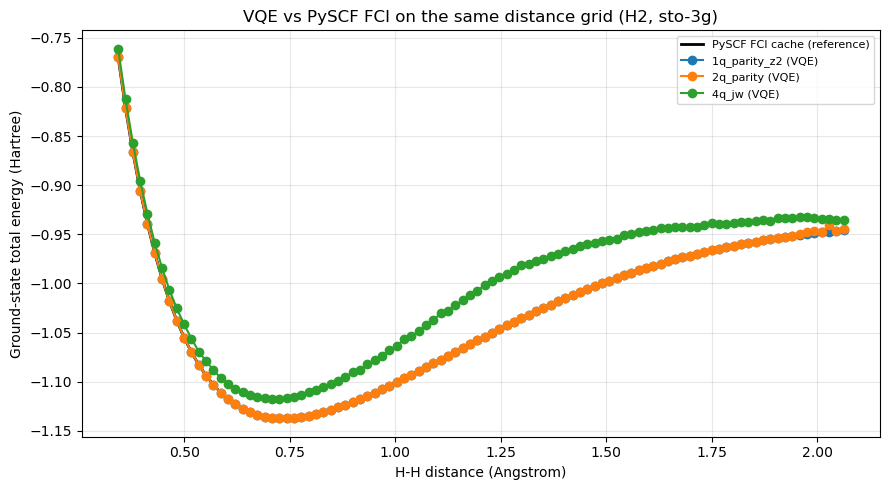

,hamiltonian,num_qubits,mean_vqe_vs_fci_error,max_vqe_vs_fci_error,mean_exact_vs_fci_error,max_exact_vs_fci_error,mean_eval_count
2,4q_jw,4,2.961466e-02,5.406981e-02,1.851852e-15,6.661338e-15,120.00
1,2q_parity,2,1.562599e-04,6.855073e-03,1.119105e-15,5.329071e-15,97.66
0,1q_parity_z2,1,5.855692e-10,5.352185e-09,9.992007e-16,3.108624e-15,37.37


In [8]:
from pathlib import Path

from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
 )

# Resolve project root whether notebook cwd is root or notebooks/
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "data").exists() else cwd.parent

fci_dir = project_root / "data" / "H2" / "sto-3g"
fci_files = sorted(fci_dir.glob("fci_*.csv"), key=lambda p: p.stat().st_mtime)
if not fci_files:
    raise FileNotFoundError(f"No FCI cache files found in {fci_dir}")

fci_file = fci_files[-1]
fci_df = pd.read_csv(fci_file).sort_values("distance").reset_index(drop=True)

print("Using FCI cache file:", fci_file.name)
print("FCI distance range:", (float(fci_df["distance"].min()), float(fci_df["distance"].max())))

basis = "sto-3g"
active_space = (2, 2)

# Leave as None to use all FCI points (fair comparison).
max_points = None
if max_points is None:
    distances_eval = fci_df["distance"].values
else:
    distances_eval = fci_df["distance"].values[:max_points]

rows_fair = []
for d in distances_eval:
    atom = f"H 0 0 0; H 0 0 {float(d)}"

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )
    ferm_op, const = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )

    qubit_ops = {
        "4q_jw": build_qubit_hamiltonian(ferm_op, mapper="jw"),
        "2q_parity": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=False,
            problem=problem,
            num_particles=problem.num_particles,
        ),
        "1q_parity_z2": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=True,
            problem=problem,
            num_particles=problem.num_particles,
        ),
    }

    fci_ref = float(fci_df.loc[np.isclose(fci_df["distance"].values, d), "energy"].iloc[0])

    for label, qop in qubit_ops.items():
        ansatz = build_ansatz(
            name="real_amplitudes",
            num_qubits=qop.num_qubits,
            reps=2,
        )
        optimizer = get_optimizer("cobyla", max_iter=120)

        vqe_res = run_vqe(
            qubit_op=qop,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=float(const),
            seed=137,
        )

        exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
        exact_total = float(np.real(exact.eigenvalue) + float(const))

        rows_fair.append({
            "distance": float(d),
            "hamiltonian": label,
            "num_qubits": qop.num_qubits,
            "num_terms": len(pauli_terms_from_qubit_hamiltonian(qop)),
            "fci_pyscf_energy": fci_ref,
            "vqe_total_energy": float(vqe_res["energy"]),
            "exact_total_energy": exact_total,
            "vqe_vs_fci_abs_error": abs(float(vqe_res["energy"]) - fci_ref),
            "exact_vs_fci_abs_error": abs(exact_total - fci_ref),
            "eval_count": int(vqe_res["eval_count"]),
        })

compare_fair = pd.DataFrame(rows_fair)
display(compare_fair.head(9))

plt.figure(figsize=(9, 5))
fci_plot = fci_df[fci_df["distance"].isin(distances_eval)]
plt.plot(
    fci_plot["distance"],
    fci_plot["energy"],
    color="black",
    linewidth=2,
    label="PySCF FCI cache (reference)",
 )

for label in sorted(compare_fair["hamiltonian"].unique()):
    sub = compare_fair[compare_fair["hamiltonian"] == label].sort_values("distance")
    plt.plot(sub["distance"], sub["vqe_total_energy"], marker="o", label=f"{label} (VQE)")

plt.xlabel("H-H distance (Angstrom)")
plt.ylabel("Ground-state total energy (Hartree)")
plt.title("VQE vs PySCF FCI on the same distance grid (H2, sto-3g)")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

fci_summary_fair = (
    compare_fair.groupby(["hamiltonian", "num_qubits"], as_index=False)
    .agg(
        mean_vqe_vs_fci_error=("vqe_vs_fci_abs_error", "mean"),
        max_vqe_vs_fci_error=("vqe_vs_fci_abs_error", "max"),
        mean_exact_vs_fci_error=("exact_vs_fci_abs_error", "mean"),
        max_exact_vs_fci_error=("exact_vs_fci_abs_error", "max"),
        mean_eval_count=("eval_count", "mean"),
    )
    .sort_values("num_qubits", ascending=False)
)
display(fci_summary_fair)

## VQE Fourier Analysis

This section performs a Fourier analysis of the VQE energy curve as a function of the bond distance. We extract the Fourier coefficients and analyze how they vary with distance, providing insight into the structure of the energy landscape.

Distance = 0.74 A
Num qubits after tapering = 1
Pauli terms: SparsePauliOp(['I', 'Z', 'X'],
              coeffs=[-1.04217492+0.j, -0.78968873+0.j, -0.18121046+0.j])
Using n_harmonics = 3
RMSE = 1.823e-16 Ha
Max |error| = 6.661e-16 Ha


,k,a_k,b_k,amplitude
0,1,-7.896887e-01,-1.812105e-01,8.102133e-01
127,128,-1.110223e-16,-0.000000e+00,1.110223e-16
23,24,-1.811843e-17,7.744196e-17,7.953323e-17
24,25,7.653152e-17,1.877819e-17,7.880161e-17
64,65,7.632783e-17,-6.938894e-18,7.664259e-17
22,23,-5.550302e-17,2.856973e-17,6.242447e-17
62,63,3.469447e-17,-4.857226e-17,5.969062e-17
126,127,-5.551115e-17,-0.000000e+00,5.551115e-17
47,48,1.626730e-17,-4.876196e-17,5.140383e-17
15,16,-4.713387e-17,1.851421e-17,5.063968e-17


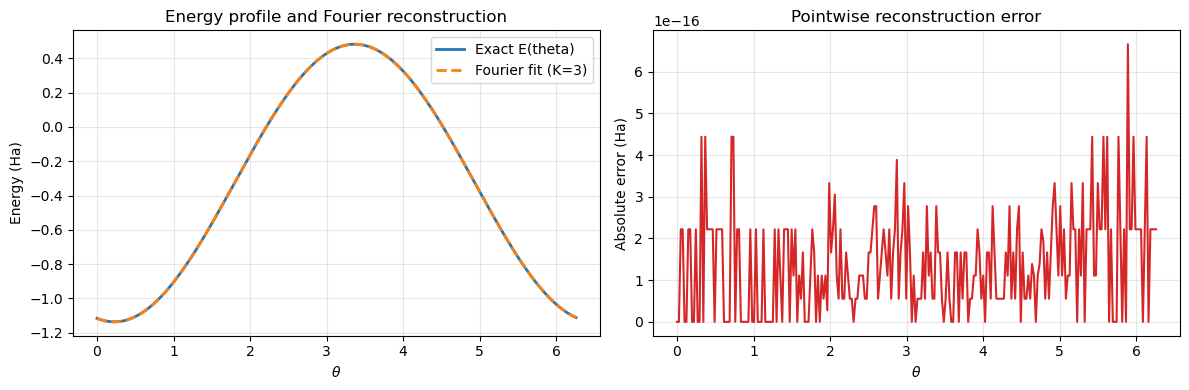

min exact sampled E = -1.13727499 Ha at theta = 0.2209
min fit E          = -1.13727499 Ha at theta = 0.2209


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import Statevector

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)

# --- 1) Build a 1-qubit effective Hamiltonian for H2 at fixed distance ---
distance = 0.74
basis = "sto-3g"
atom = f"H 0 0 0; H 0 0 {distance}"

problem = build_electronic_problem(
    atom_string=atom,
    basis=basis,
    active_space=(2, 2),
    freeze_core=False,
)

ferm_op, const_energy = build_electronic_hamiltonian(
    atom_string=atom,
    basis=basis,
    active_space=(2, 2),
    freeze_core=False,
)

qubit_op = build_qubit_hamiltonian(
    ferm_op,
    mapper="parity",
    z2symmetry_reduction=True,
    problem=problem,
    num_particles=problem.num_particles,
).simplify()

print(f"Distance = {distance:.2f} A")
print(f"Num qubits after tapering = {qubit_op.num_qubits}")
print("Pauli terms:", qubit_op)

# --- 2) Define a one-parameter trial state and sample E(theta) ---
theta = Parameter("theta")
ansatz_1p = QuantumCircuit(qubit_op.num_qubits)
ansatz_1p.ry(theta, 0)

def energy_theta(theta_value: float) -> float:
    state = Statevector.from_instruction(
        ansatz_1p.assign_parameters({theta: float(theta_value)})
    )
    return float(np.real(state.expectation_value(qubit_op)) + const_energy)

N = 256
theta_grid = np.linspace(0, 2 * np.pi, N, endpoint=False)
energy_samples = np.array([energy_theta(t) for t in theta_grid])

# --- 3) Discrete Fourier transform: E(theta) ~ a0/2 + sum_k [a_k cos(k theta) + b_k sin(k theta)] ---
fft_r = np.fft.rfft(energy_samples) / N
a0 = 2.0 * fft_r[0].real
ak_all = 2.0 * fft_r[1:].real
bk_all = -2.0 * fft_r[1:].imag

def fourier_reconstruct(theta_values: np.ndarray, n_harmonics: int) -> np.ndarray:
    n_harmonics = max(1, min(n_harmonics, len(ak_all)))
    rec = np.full(theta_values.shape, a0 / 2.0, dtype=float)
    k = np.arange(1, n_harmonics + 1)[:, None]
    rec += (
        ak_all[:n_harmonics, None] * np.cos(k * theta_values)
        + bk_all[:n_harmonics, None] * np.sin(k * theta_values)
    ).sum(axis=0)
    return rec

n_harmonics = 3
energy_fit = fourier_reconstruct(theta_grid, n_harmonics=n_harmonics)

rmse = float(np.sqrt(np.mean((energy_samples - energy_fit) ** 2)))
max_abs_err = float(np.max(np.abs(energy_samples - energy_fit)))

print(f"Using n_harmonics = {n_harmonics}")
print(f"RMSE = {rmse:.3e} Ha")
print(f"Max |error| = {max_abs_err:.3e} Ha")

coef_df = pd.DataFrame(
    {
        "k": np.arange(1, len(ak_all) + 1),
        "a_k": ak_all,
        "b_k": bk_all,
        "amplitude": np.sqrt(ak_all**2 + bk_all**2),
    }
).sort_values("amplitude", ascending=False)

display(coef_df.head(10))

# --- 4) Plot exact samples vs truncated Fourier series ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(theta_grid, energy_samples, lw=2, label="Exact E(theta)")
ax[0].plot(theta_grid, energy_fit, "--", lw=2, label=f"Fourier fit (K={n_harmonics})")
ax[0].set_xlabel(r"$\theta$")
ax[0].set_ylabel("Energy (Ha)")
ax[0].set_title("Energy profile and Fourier reconstruction")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(theta_grid, np.abs(energy_samples - energy_fit), color="tab:red")
ax[1].set_xlabel(r"$\theta$")
ax[1].set_ylabel("Absolute error (Ha)")
ax[1].set_title("Pointwise reconstruction error")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: estimated minima from exact sampled curve and Fourier fit
idx_exact = int(np.argmin(energy_samples))
idx_fit = int(np.argmin(energy_fit))
print(f"min exact sampled E = {energy_samples[idx_exact]:.8f} Ha at theta = {theta_grid[idx_exact]:.4f}")
print(f"min fit E          = {energy_fit[idx_fit]:.8f} Ha at theta = {theta_grid[idx_fit]:.4f}")

### Fourier Coefficients vs Distance (Step 1)

This section sweeps the H-H distance and extracts Fourier coefficients of
$E(\theta)$ using a 1-parameter ansatz:

$$
E(\theta) \approx \frac{a_0}{2} + a_1\cos(\theta) + b_1\sin(\theta).
$$

We then compare the minimum predicted by the first harmonic against the exact sampled minimum.

,distance,a0_half,a1,b1,amp1,theta_min_h1,theta_min_exact,e_min_h1,e_min_exact,abs_err_min
0,0.500000,0.123163,-1.166159,-0.168870,1.178323,0.143809,0.147262,-1.055160,-1.055153,7.024333e-06
1,0.642857,-0.190381,-0.921434,-0.175943,0.938081,0.188673,0.196350,-1.128462,-1.128435,2.763656e-05
2,0.785714,-0.376901,-0.735814,-0.183803,0.758423,0.244786,0.245437,-1.135325,-1.135325,1.608376e-07
3,0.928571,-0.491081,-0.593993,-0.192323,0.624352,0.313128,0.294524,-1.115433,-1.115325,1.080385e-04
4,1.071429,-0.562899,-0.482347,-0.201367,0.522693,0.395478,0.392699,-1.085591,-1.085589,2.018547e-06
5,1.214286,-0.608378,-0.392167,-0.210736,0.445202,0.493090,0.490874,-1.053580,-1.053579,1.093350e-06
6,1.357143,-0.636434,-0.318509,-0.220199,0.387215,0.604891,0.589049,-1.023650,-1.023601,4.859301e-05
7,1.500000,-0.652671,-0.258203,-0.229536,0.345478,0.726691,0.736311,-0.998149,-0.998133,1.598519e-05
8,1.642857,-0.660937,-0.208829,-0.238572,0.317059,0.851780,0.834486,-0.977996,-0.977949,4.741467e-05
9,1.785714,-0.663939,-0.168430,-0.247183,0.299112,0.972664,0.981748,-0.963051,-0.963039,1.234077e-05


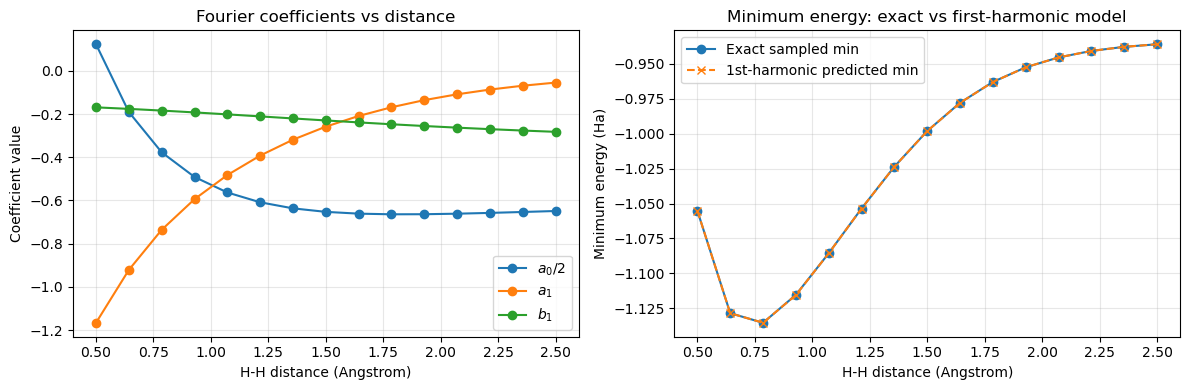

Mean |E_min(h1) - E_min(exact)|: 2.091384179469339e-05
Max  |E_min(h1) - E_min(exact)|: 0.00010803850177842911


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import Statevector

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)

basis = "sto-3g"
active_space = (2, 2)
distances_scan = np.linspace(0.5, 2.5, 15)
N_theta = 128
theta_grid = np.linspace(0, 2 * np.pi, N_theta, endpoint=False)

theta = Parameter("theta")
rows_fourier = []

for d in distances_scan:
    atom = f"H 0 0 0; H 0 0 {float(d)}"

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )

    ferm_op, const_energy = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )

    qubit_op = build_qubit_hamiltonian(
        ferm_op,
        mapper="parity",
        z2symmetry_reduction=True,
        problem=problem,
        num_particles=problem.num_particles,
    ).simplify()

    ansatz_1p = QuantumCircuit(qubit_op.num_qubits)
    ansatz_1p.ry(theta, 0)

    def energy_theta(theta_value: float) -> float:
        state = Statevector.from_instruction(
            ansatz_1p.assign_parameters({theta: float(theta_value)})
        )
        return float(np.real(state.expectation_value(qubit_op)) + const_energy)

    energy_samples = np.array([energy_theta(t) for t in theta_grid])

    fft_r = np.fft.rfft(energy_samples) / N_theta
    a0_half = float(fft_r[0].real)

    if len(fft_r) > 1:
        a1 = float(2.0 * fft_r[1].real)
        b1 = float(-2.0 * fft_r[1].imag)
    else:
        a1 = 0.0
        b1 = 0.0

    amp1 = float(np.sqrt(a1**2 + b1**2))
    theta_min_h1 = float((np.arctan2(b1, a1) + np.pi) % (2 * np.pi))
    e_min_h1 = float(a0_half - amp1)

    idx_exact = int(np.argmin(energy_samples))
    e_min_exact = float(energy_samples[idx_exact])
    theta_min_exact = float(theta_grid[idx_exact])

    rows_fourier.append(
        {
            "distance": float(d),
            "a0_half": a0_half,
            "a1": a1,
            "b1": b1,
            "amp1": amp1,
            "theta_min_h1": theta_min_h1,
            "theta_min_exact": theta_min_exact,
            "e_min_h1": e_min_h1,
            "e_min_exact": e_min_exact,
            "abs_err_min": abs(e_min_h1 - e_min_exact),
        }
    )

fourier_df = pd.DataFrame(rows_fourier)
display(fourier_df)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(fourier_df["distance"], fourier_df["a0_half"], marker="o", label=r"$a_0/2$")
ax[0].plot(fourier_df["distance"], fourier_df["a1"], marker="o", label=r"$a_1$")
ax[0].plot(fourier_df["distance"], fourier_df["b1"], marker="o", label=r"$b_1$")
ax[0].set_xlabel("H-H distance (Angstrom)")
ax[0].set_ylabel("Coefficient value")
ax[0].set_title("Fourier coefficients vs distance")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(fourier_df["distance"], fourier_df["e_min_exact"], marker="o", label="Exact sampled min")
ax[1].plot(fourier_df["distance"], fourier_df["e_min_h1"], "--", marker="x", label="1st-harmonic predicted min")
ax[1].set_xlabel("H-H distance (Angstrom)")
ax[1].set_ylabel("Minimum energy (Ha)")
ax[1].set_title("Minimum energy: exact vs first-harmonic model")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

print("Mean |E_min(h1) - E_min(exact)|:", float(fourier_df["abs_err_min"].mean()))
print("Max  |E_min(h1) - E_min(exact)|:", float(fourier_df["abs_err_min"].max()))

### Fourier-Guided Initialization vs Random Initialization

Idea: for each distance, start the optimizer near the angle predicted by the first harmonic model,
$$\theta_0 \approx \operatorname{atan2}(b_1, a_1) + \pi$$
, and compare convergence against random initialization.

Now we test whether using the first-harmonic angle estimate
$\theta_0 \approx \theta_{\min}^{(h1)}$
improves VQE convergence compared to random initialization.

For each distance, we run multiple trials and compare:
- number of function evaluations,
- absolute energy error relative to exact diagonalization.

,mode,mean_eval_count,std_eval_count,mean_abs_error,max_abs_error
0,fourier_guided,23.186667,1.204646,1.732041e-10,1.170120e-09
1,random,24.720000,2.003780,1.868067e-10,9.954251e-10


,distance,mode,mean_eval_count,mean_abs_error
0,0.500000,fourier_guided,23.4,3.554804e-10
1,0.500000,random,24.4,5.662173e-10
2,0.642857,fourier_guided,22.6,4.176120e-10
3,0.642857,random,25.0,3.294259e-10
4,0.785714,fourier_guided,22.4,3.845742e-10
5,0.785714,random,24.2,1.557132e-10
6,0.928571,fourier_guided,23.2,2.214748e-10
7,0.928571,random,26.2,2.527187e-10
8,1.071429,fourier_guided,23.6,2.590193e-10
9,1.071429,random,24.0,2.935583e-10


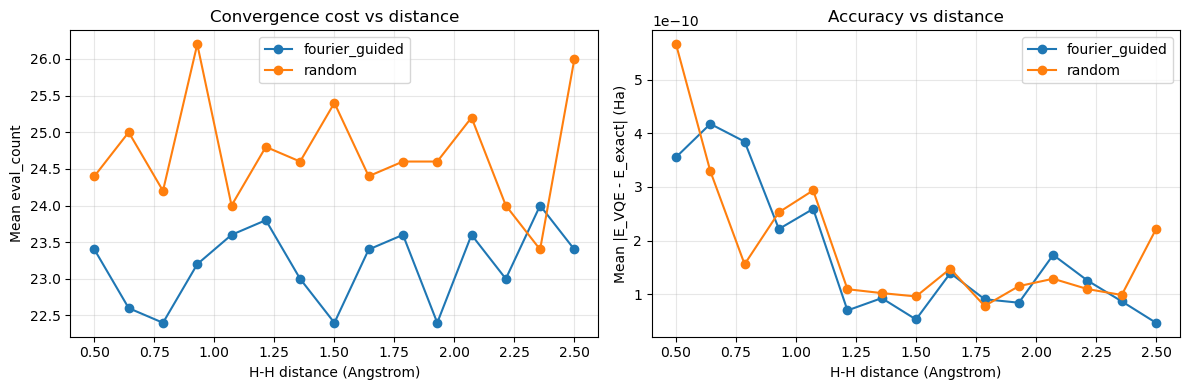

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe

if "fourier_df" not in globals():
    raise RuntimeError("Run Step 1 first to generate fourier_df.")

rng = np.random.default_rng(2026)
trials_per_distance = 5
sigma_theta = 0.20

rows_init = []

for _, row in fourier_df.iterrows():
    d = float(row["distance"])
    theta_h1 = float(row["theta_min_h1"])

    atom = f"H 0 0 0; H 0 0 {d}"
    problem = build_electronic_problem(
        atom_string=atom,
        basis="sto-3g",
        active_space=(2, 2),
        freeze_core=False,
    )
    ferm_op, const_energy = build_electronic_hamiltonian(
        atom_string=atom,
        basis="sto-3g",
        active_space=(2, 2),
        freeze_core=False,
    )

    qubit_op = build_qubit_hamiltonian(
        ferm_op,
        mapper="parity",
        z2symmetry_reduction=True,
        problem=problem,
        num_particles=problem.num_particles,
    ).simplify()

    exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    exact_total = float(np.real(exact.eigenvalue) + float(const_energy))

    theta = Parameter("theta")
    ansatz = QuantumCircuit(qubit_op.num_qubits)
    ansatz.ry(theta, 0)

    for trial in range(trials_per_distance):
        init_modes = {
            "fourier_guided": np.array([
                ((theta_h1 + rng.normal(0.0, sigma_theta) + np.pi) % (2 * np.pi)) - np.pi
            ]),
            "random": rng.uniform(-np.pi, np.pi, size=1),
        }

        for mode, init_point in init_modes.items():
            optimizer = get_optimizer("cobyla", max_iter=80)
            res = run_vqe(
                qubit_op=qubit_op,
                ansatz=ansatz,
                optimizer=optimizer,
                initial_point=init_point,
                constant_energy=float(const_energy),
                seed=137 + trial,
            )

            rows_init.append(
                {
                    "distance": d,
                    "mode": mode,
                    "trial": trial,
                    "init_theta": float(init_point[0]),
                    "vqe_energy": float(res["energy"]),
                    "exact_energy": exact_total,
                    "abs_error": abs(float(res["energy"]) - exact_total),
                    "eval_count": int(res["eval_count"]),
                }
            )

init_df = pd.DataFrame(rows_init)
summary_init = (
    init_df.groupby("mode", as_index=False)
    .agg(
        mean_eval_count=("eval_count", "mean"),
        std_eval_count=("eval_count", "std"),
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
    )
)

display(summary_init)

display(
    init_df.groupby(["distance", "mode"], as_index=False)
    .agg(
        mean_eval_count=("eval_count", "mean"),
        mean_abs_error=("abs_error", "mean"),
    )
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for mode, sub in init_df.groupby("mode"):
    sub2 = (
        sub.groupby("distance", as_index=False)
        .agg(mean_eval=("eval_count", "mean"), mean_err=("abs_error", "mean"))
        .sort_values("distance")
    )
    ax[0].plot(sub2["distance"], sub2["mean_eval"], marker="o", label=mode)
    ax[1].plot(sub2["distance"], sub2["mean_err"], marker="o", label=mode)

ax[0].set_xlabel("H-H distance (Angstrom)")
ax[0].set_ylabel("Mean eval_count")
ax[0].set_title("Convergence cost vs distance")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].set_xlabel("H-H distance (Angstrom)")
ax[1].set_ylabel("Mean |E_VQE - E_exact| (Ha)")
ax[1].set_title("Accuracy vs distance")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()